## Análisis visual y Matplotlib

In [3]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd 
import seaborn as sns
%matplotlib inline
#para evitar el plt.show() por grafico

In [54]:
df = pd.read_csv('datos-covid-etareo.csv')
df.head(49)

,Grupo de edad,Sexo,Fecha,Contagios
0,00 - 04 años,M,2020-03-25,4
1,05 - 09 años,M,2020-03-25,2
2,10 - 14 años,M,2020-03-25,7
3,15 - 19 años,M,2020-03-25,8
4,20 - 24 años,M,2020-03-25,25
5,25 - 29 años,M,2020-03-25,61
6,30 - 34 años,M,2020-03-25,88
7,35 - 39 años,M,2020-03-25,72
8,40 - 44 años,M,2020-03-25,62
9,45 - 49 años,M,2020-03-25,47


In [8]:
df['Grupo de edad'].unique()

array(['00 - 04 años', '05 - 09 años', '10 - 14 años', '15 - 19 años',
       '20 - 24 años', '25 - 29 años', '30 - 34 años', '35 - 39 años',
       '40 - 44 años', '45 - 49 años', '50 - 54 años', '55 - 59 años',
       '60 - 64 años', '65 - 69 años', '70 - 74 años', '75 - 79 años',
       '80 y más años'], dtype=object)

In [9]:
print(df['Fecha'].min(),df['Fecha'].max())

2020-03-25 2020-11-13


In [55]:
data = df.groupby('Fecha', as_index=False)['Contagios'].sum()
data

,Fecha,Contagios
0,2020-03-25,1012
1,2020-03-26,1252
2,2020-03-27,1434
3,2020-03-28,1723
4,2020-03-29,1906
...,...,...
87,2020-10-30,561152
88,2020-11-02,566515
89,2020-11-06,572664
90,2020-11-09,577877


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Fecha      92 non-null     object
 1   Contagios  92 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.6+ KB


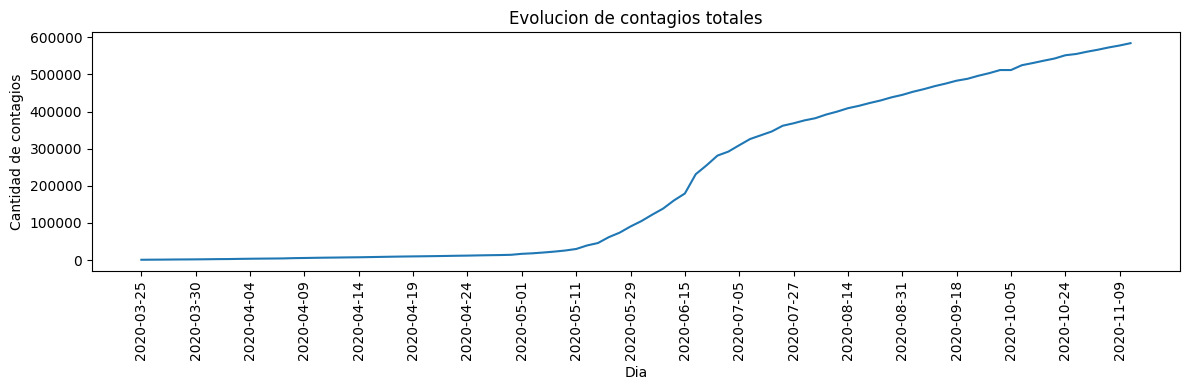

In [12]:
plt.figure(figsize=(12,4))
plt.plot(data['Fecha'],data['Contagios'])
plt.title('Evolucion de contagios totales')
plt.xlabel('Dia')
plt.ylabel('Cantidad de contagios')
plt.xticks(data['Fecha'][::5], rotation=90)  # muestra 1 cada 5 de las etiquetas(cuando son muchas)
plt.tight_layout()#ajusta cierta data para ajustar el grafico y limpiarlo

In [20]:
df.columns

Index(['Grupo de edad', 'Sexo', 'Fecha', 'Contagios'], dtype='object')

In [56]:
#subgraficos
data_M = df[df['Sexo'] == 'M'].groupby('Fecha', as_index=False)['Contagios'].sum()
print(data_M)
print('-----------------------')
data_F = df[df['Sexo'] == 'F'].groupby('Fecha', as_index=False)['Contagios'].sum()
print(data_F)

         Fecha  Contagios
0   2020-03-25        496
1   2020-03-26        610
2   2020-03-27        704
3   2020-03-28        867
4   2020-03-29        959
..         ...        ...
87  2020-10-30     284758
88  2020-11-02     287285
89  2020-11-06     290367
90  2020-11-09     292926
91  2020-11-13     296024

[92 rows x 2 columns]
-----------------------
         Fecha  Contagios
0   2020-03-25        516
1   2020-03-26        642
2   2020-03-27        730
3   2020-03-28        856
4   2020-03-29        947
..         ...        ...
87  2020-10-30     276394
88  2020-11-02     279230
89  2020-11-06     282297
90  2020-11-09     284951
91  2020-11-13     288126

[92 rows x 2 columns]


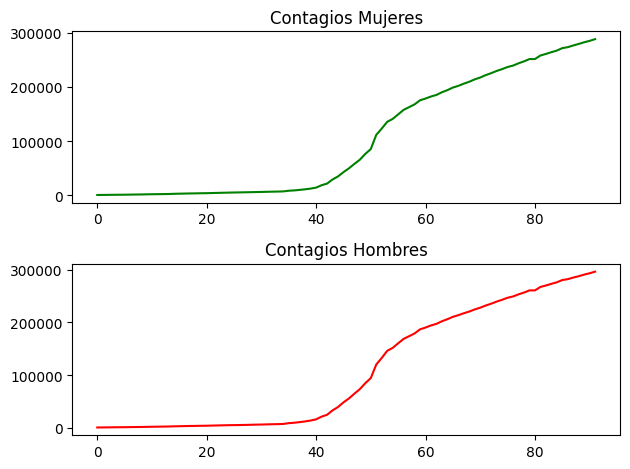

In [14]:
plt.subplot(2,1,2)
plt.plot(data_M['Contagios'],'r')
plt.title('Contagios Hombres')

plt.subplot(2,1,1)
plt.plot(data_F['Contagios'],'g')
plt.title('Contagios Mujeres')

plt.tight_layout()

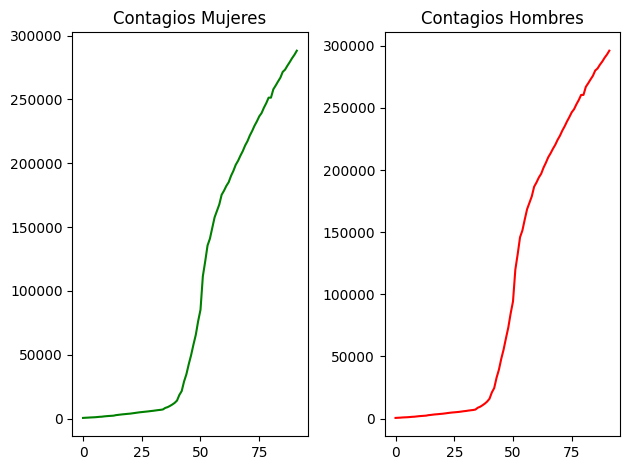

In [23]:
#plt.figure(figsize=(12,6))

plt.subplot(1,2,2)
plt.plot(data_M['Contagios'],'r')
plt.title('Contagios Hombres')

plt.subplot(1,2,1)
plt.plot(data_F['Contagios'],'g')
plt.title('Contagios Mujeres')

plt.tight_layout()

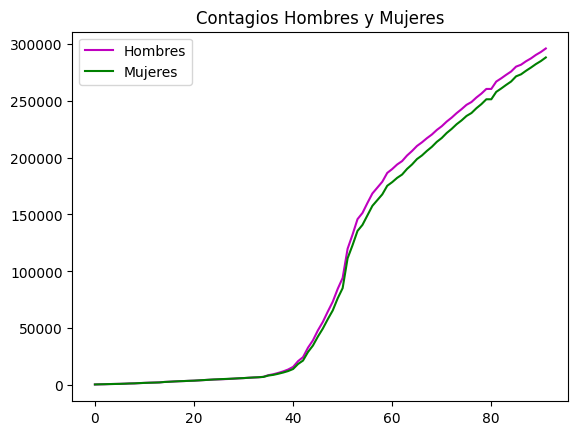

In [ ]:
#al tener los mismos datos de ejes. se pueden juntar para comparar
plt.plot(data_M['Contagios'],'m') #aqui igual se puede indicar legend='Hombres'
plt.plot(data_F['Contagios'],'g')
plt.title('Contagios Hombres y Mujeres')
plt.legend(['Hombres','Mujeres'])

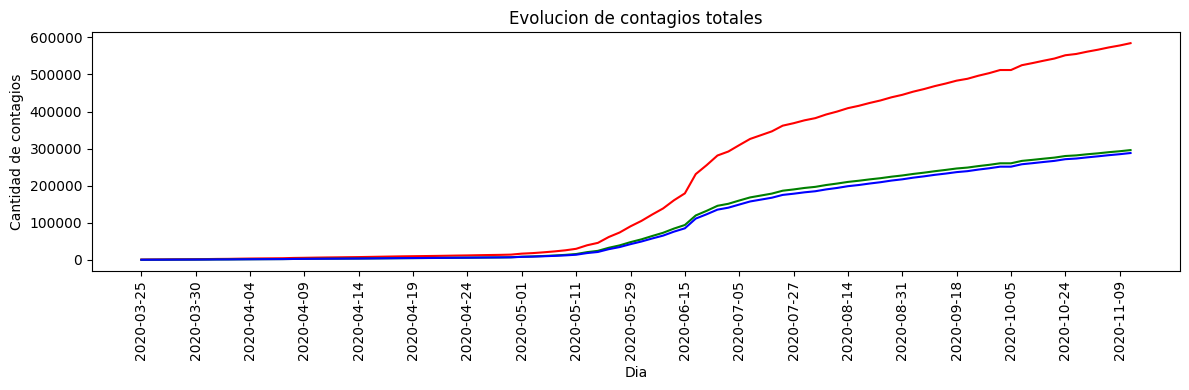

In [19]:
plt.figure(figsize=(12,4))
plt.plot(data['Fecha'],data['Contagios'],'r')
plt.plot(data_M['Fecha'],data_M['Contagios'],'g')
plt.plot(data_F['Fecha'],data_F['Contagios'],'b')

plt.title('Evolucion de contagios totales')
plt.xlabel('Dia')
plt.ylabel('Cantidad de contagios')
plt.xticks(data['Fecha'][::5], rotation=90)  # muestra 1 cada 5 de las etiquetas(cuando son muchas)
plt.tight_layout()#ajusta cierta data para ajustar el grafico y limpiarlo

### Utilizando la orientación a objetos en la libreria Matplotlib


Text(0.5, 1.0, 'Total de Contagiados')

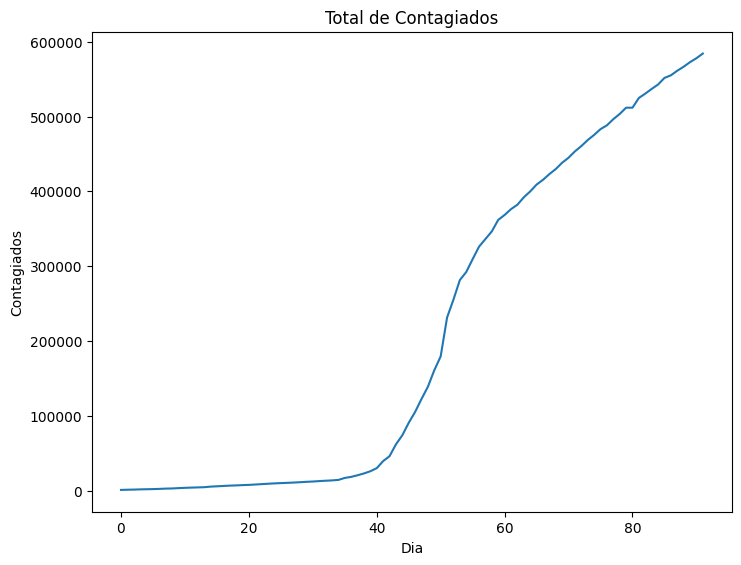

In [34]:
fig = plt.figure()
axe = fig.add_axes([0,0,1,1])
axe.plot(data["Contagios"])
axe.set_xlabel('Dia')
axe.set_ylabel('Contagiados')
axe.set_title('Total de Contagiados')

### Grilla de gráficos con orientación a objetos

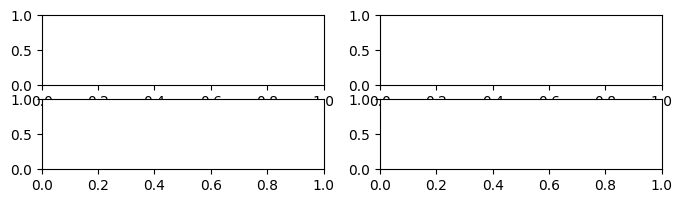

In [33]:
fig, axes = plt.subplots( nrows=2 , ncols=2,figsize=(8,2) )


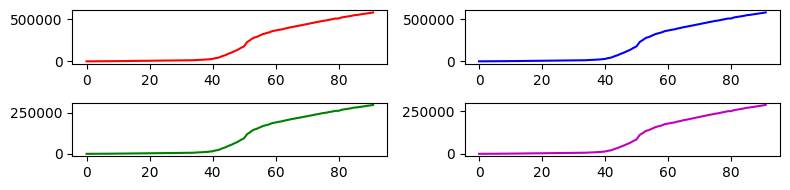

In [ ]:
fig, axes = plt.subplots( nrows=2 , ncols=2,figsize=(8,2) )
axes[0][0].plot(data["Contagios"],'r') #superior izquierda
axes[1][0].plot(data_M["Contagios"],'g') # inferior izquierda
axes[0][1].plot(data["Contagios"],'b') # superior derecha
axes[1][1].plot(data_F["Contagios"],'m') # inferior derecha
plt.tight_layout()

### Posicionando varios ejes en una misma figura

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

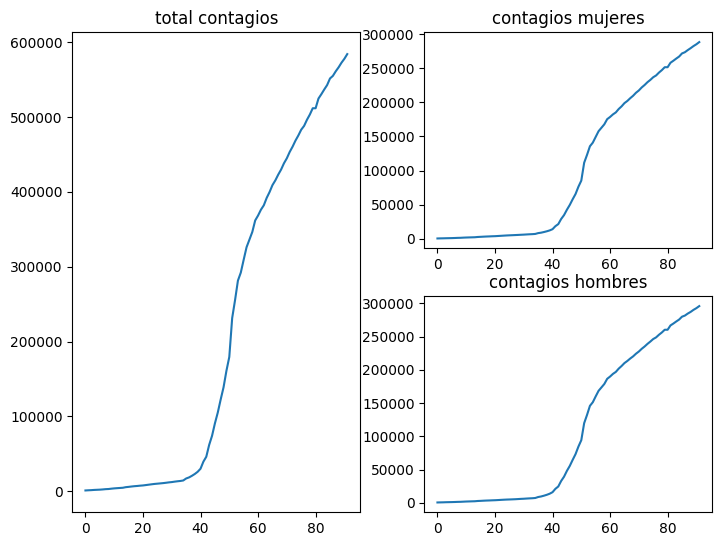

In [35]:
#Posicionando varios ejes en una misma figura
fig=plt.figure()
axe1=fig.add_axes([0, 0, 0.45, 1])   # (x,y) origen (x+d,y+d):  [origen_x , origen_y , ancho , alto]
axe2=fig.add_axes([0.55, 0, 0.45, 0.45])    
axe3=fig.add_axes([0.55, 0.55, 0.45, 0.45])   

axe1.plot(data['Contagios'])
axe2.plot(data_M['Contagios'])
axe3.plot(data_F['Contagios'])

axe1.set_title('total contagios')
axe2.set_title('contagios hombres')
axe3.set_title('contagios mujeres')

plt.tight_layout

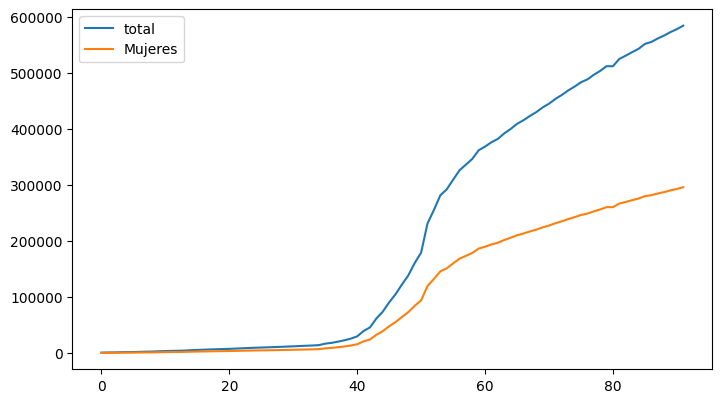

In [39]:
fig = plt.figure()
axe = fig.add_axes([0.2, 0.2, 1, 0.75])
axe.plot(data["Contagios"], label='total')
axe.plot(data_M["Contagios"], label='Mujeres')
axe.legend(loc=0) #posicion legenda

In [ ]:
#para guardar imagen o grafico
fig.savefig('prueba_graf.jpeg', dpi=100, bbox_inches='tight')
#bbox_inches='tight' matplotlib recalcula la “caja” para incluir TODO lo visible, aunque esté fuera del área estándar.
"""
DPI = Dots Per Inch (puntos por pulgada):Es básicamente la resolución de la imagen cuando la guardas.

Ejemplos típicos
dpi=72 → baja calidad (pantalla)
dpi=100 → calidad normal (lo que estás usando 👍)
dpi=300 → alta calidad (ideal para informes o impresión)
dpi=600 → muy alta calidad (profesional/impresión fina)
"""

'\nDPI = Dots Per Inch (puntos por pulgada):Es básicamente la resolución de la imagen cuando la guardas.\n\nEjemplos típicos\ndpi=72 → baja calidad (pantalla)\ndpi=100 → calidad normal (lo que estás usando 👍)\ndpi=300 → alta calidad (ideal para informes o impresión)\ndpi=600 → muy alta calidad (profesional/impresión fina)\n'

### Personalizando la apariencia

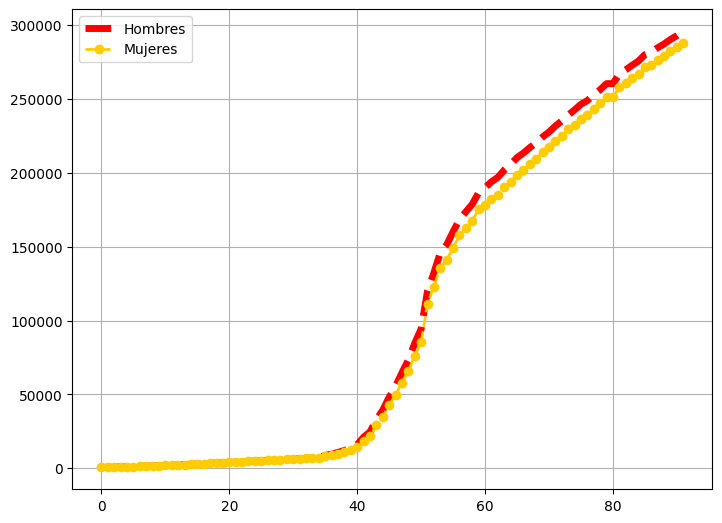

In [40]:
fig = plt.figure()
axe = fig.add_axes([0,0,1,1])
axe.plot(data_M["Contagios"], label='Hombres', color='red', linestyle='dashed', linewidth=5)
axe.plot(data_F["Contagios"], label='Mujeres', c='#FFCC00', ls='--', lw=2, marker='o')
axe.legend(loc=0)
axe.grid()

### Límites del gráfico

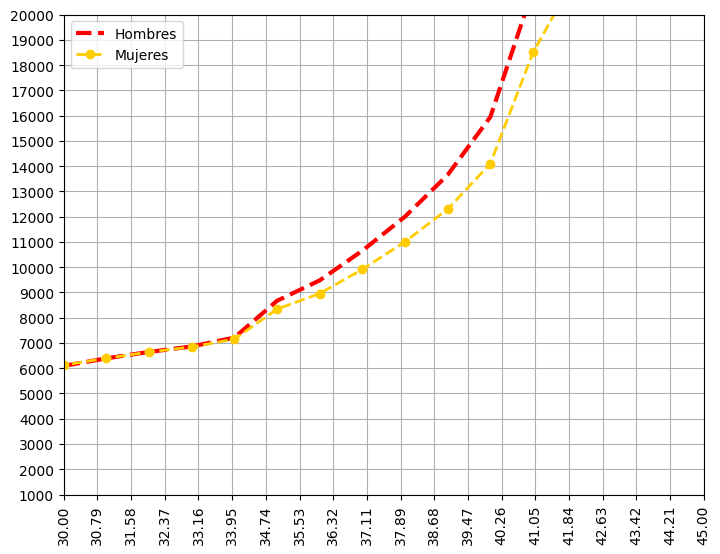

In [46]:
import matplotlib.ticker as ticker
fig = plt.figure()
axe = fig.add_axes([0,0,1,1])
axe.plot(data_M["Contagios"], label='Hombres', color='red', linestyle='dashed', linewidth=3)
axe.plot(data_F["Contagios"], label='Mujeres', c='#FFCC00', ls='--', lw=2, marker='o')
axe.set_xlim( [30,45] )
axe.set_ylim( [1000,20000] )
axe.xaxis.set_major_locator(ticker.LinearLocator(20))
axe.yaxis.set_major_locator(ticker.MultipleLocator(1000))
plt.xticks(rotation=90)
axe.legend(loc=2)#0 automatico, 1:arriba derecha 2:arriba izquierda..
axe.grid()

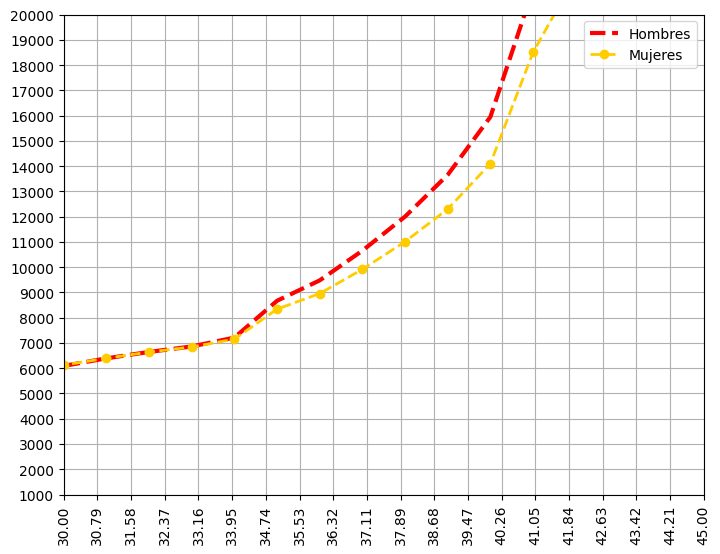

In [47]:
import matplotlib.ticker as ticker
fig = plt.figure()
axe = fig.add_axes([0,0,1,1])
axe.plot(data_M["Contagios"], label='Hombres', color='red', linestyle='dashed', linewidth=3)
axe.plot(data_F["Contagios"], label='Mujeres', c='#FFCC00', ls='--', lw=2, marker='o')
axe.set_xlim( [30,45] )
axe.set_ylim( [1000,20000] )
axe.xaxis.set_major_locator(ticker.LinearLocator(20))
axe.yaxis.set_major_locator(ticker.MultipleLocator(1000))
plt.xticks(rotation=90)
axe.legend(loc=0)
axe.grid()

## Tipos de Gráfico

Text(0.5, 0, 'Contagios')

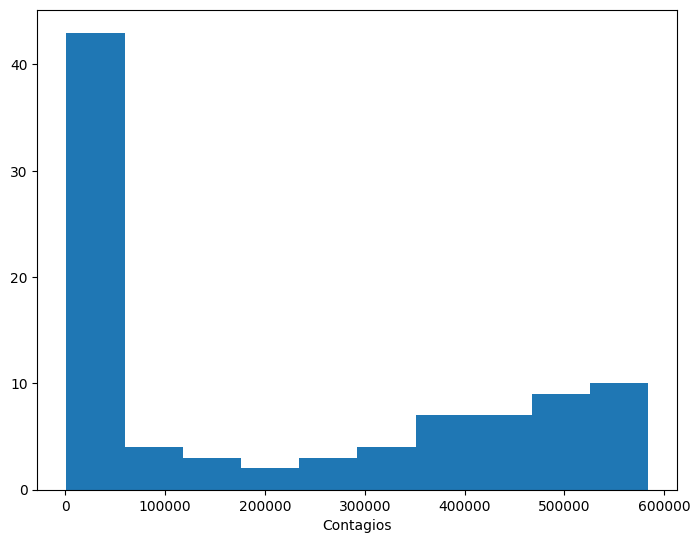

In [49]:
fig = plt.figure()
axe = fig.add_axes([0,0,1,1])

axe.hist( data['Contagios'], bins=10 )

axe.set_xlabel('Contagios')


Text(0, 0.5, 'Cant Contagios')

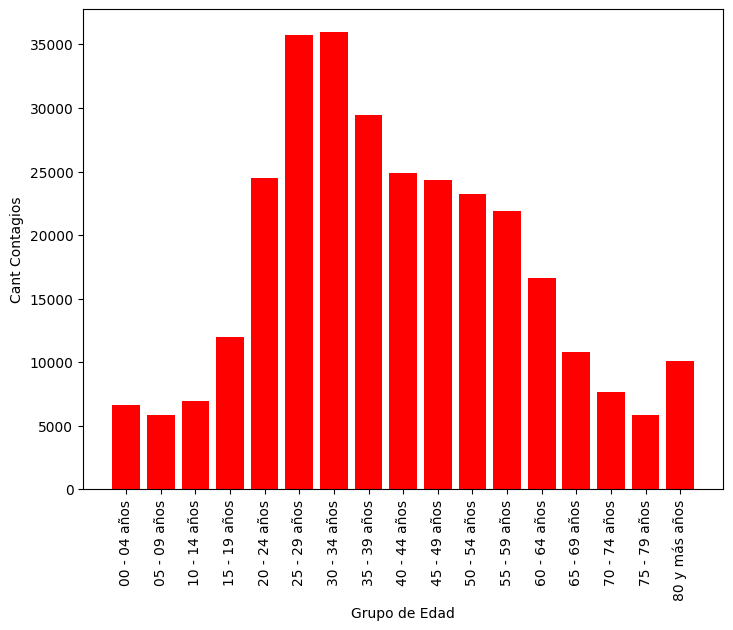

In [40]:
fig = plt.figure()
axe = fig.add_axes([0,0,1,1])

axe.bar( df['Grupo de edad'], df['Contagios'],color='r' )

axe.tick_params(axis='x', labelrotation=90)
axe.set_xlabel('Grupo de Edad')
axe.set_ylabel('Cant Contagios')

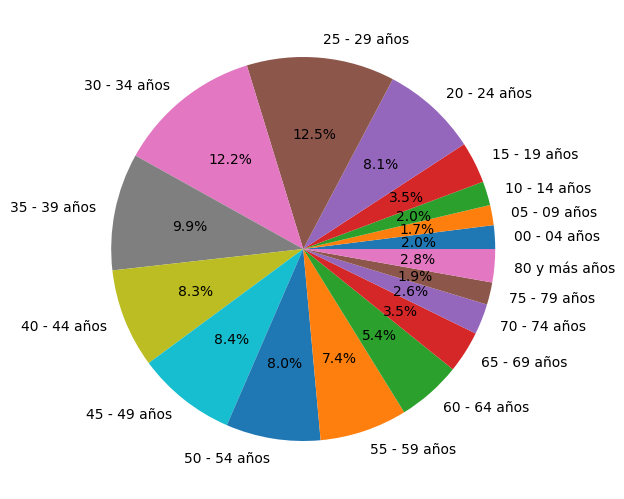

In [58]:
#Diagrama de tortas
datax = df.groupby('Grupo de edad')['Contagios'].sum()

fig = plt.figure()
axe = fig.add_axes([0,0,1,1])

axe.pie(datax, labels=datax.index, autopct='%1.1f%%')

plt.show()

In [60]:
#estilos disponibles
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [67]:
plt.style.use('classic')

In [61]:
datax

Grupo de edad
00 - 04 años      388652
05 - 09 años      331477
10 - 14 años      394820
15 - 19 años      683528
20 - 24 años     1581826
25 - 29 años     2440547
30 - 34 años     2381931
35 - 39 años     1931353
40 - 44 años     1632063
45 - 49 años     1638065
50 - 54 años     1556952
55 - 59 años     1442079
60 - 64 años     1058348
65 - 69 años      689995
70 - 74 años      504467
75 - 79 años      367548
80 y más años     546816
Name: Contagios, dtype: int64

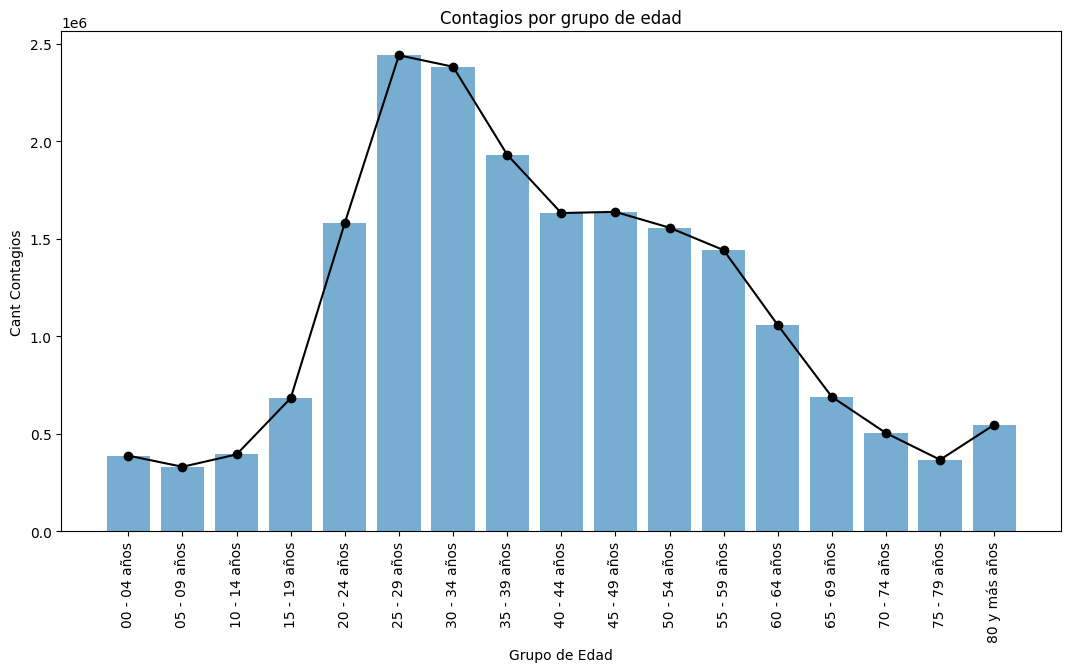

In [60]:
fig = plt.figure(figsize=(10,5))
axe = fig.add_axes([0,0,1,1])

axe.bar(datax.index, datax.values, alpha=0.6)
axe.plot(datax.index, datax.values, c='black', marker='o')

#axe.bar(data['Grupo de edad'], data['Contagios'], alpha=0.6) este no funciono porque se habia hecho un groupby y quedo como serie por eso se usa la parte de arrina data.index
#axe.plot(data['Grupo de edad'], data['Contagios'], c='black', marker='o')

axe.tick_params(axis='x', labelrotation=90)
axe.set_xlabel('Grupo de Edad')
axe.set_ylabel('Cant Contagios')
axe.set_title('Contagios por grupo de edad')

plt.show()